✅ Spark started: 3.5.0
Schema:
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

Total rows before cleaning: 3066766
Total rows after cleaning: 2998382

=== Trips by Payment Type =

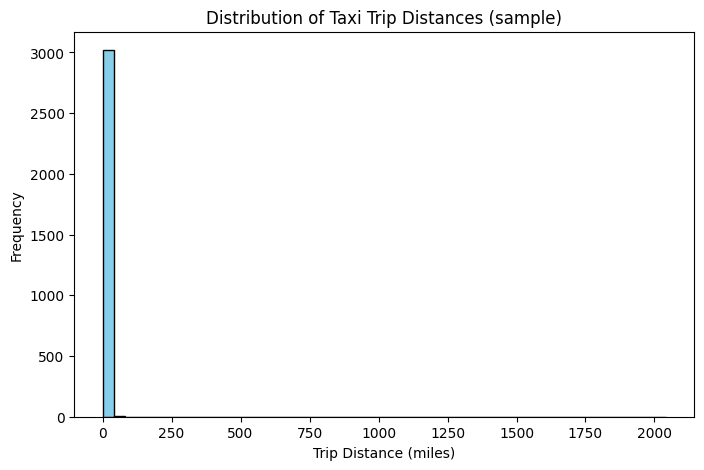


🎯 Task-1 Completed: Insights, Partitioned Output, and Visualization ready.


In [1]:
# 🚀 Big Data Analysis with PySpark (Google Colab) — Task 1

# 1) Install Java & Spark
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar -xzf spark-3.5.0-bin-hadoop3.tgz
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"
!pip install -q findspark matplotlib

# 2) Start Spark
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

spark = (SparkSession.builder
         .appName("BigData_Task1")
         .config("spark.sql.shuffle.partitions", "200")
         .getOrCreate())
print("✅ Spark started:", spark.version)

# 3) Download dataset (NYC Yellow Taxi Jan 2023)
!wget -q https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet -O taxi.parquet
df = spark.read.parquet("taxi.parquet")
print("Schema:")
df.printSchema()
print("Total rows before cleaning:", df.count())

# 4) Data Cleaning
df = (df.withColumn("fare_amount", col("fare_amount").cast("double"))
        .withColumn("trip_distance", col("trip_distance").cast("double"))
        .filter(col("trip_distance") > 0)
        .filter(col("fare_amount") > 0))
print("Total rows after cleaning:", df.count())

# 5) Analysis — Trips by Payment Type
payment_summary = (df.groupBy("payment_type")
                     .agg(F.count("*").alias("num_trips"),
                          F.avg("fare_amount").alias("avg_fare"))
                     .orderBy(F.desc("num_trips")))
print("\n=== Trips by Payment Type ===")
payment_summary.show()

# 6) Analysis — Monthly Trend
df2 = (df.withColumn("year", F.year("tpep_pickup_datetime"))
        .withColumn("month", F.month("tpep_pickup_datetime")))
monthly_trend = (df2.groupBy("year","month")
                   .agg(F.count("*").alias("trips"),
                        F.avg("fare_amount").alias("avg_fare"))
                   .orderBy("year","month"))
print("\n=== Monthly Trend ===")
monthly_trend.show(12)

# 7) Analysis — Hourly Trend
df3 = df2.withColumn("hour", F.hour("tpep_pickup_datetime"))
hourly_trend = (df3.groupBy("hour")
                   .agg(F.count("*").alias("trips"))
                   .orderBy("hour"))
print("\n=== Hourly Trend ===")
hourly_trend.show(24)

# 8) Save processed data (partitioned parquet)
(df2.write.mode("overwrite")
    .partitionBy("year","month")
    .parquet("/content/processed_taxi"))
print("\n✅ Processed data saved in /content/processed_taxi")

# 9) Visualization — Distribution of Trip Distances
sample_pdf = df.sample(0.001).toPandas()
plt.figure(figsize=(8,5))
plt.hist(sample_pdf["trip_distance"], bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")
plt.title("Distribution of Taxi Trip Distances (sample)")
plt.show()

print("\n🎯 Task-1 Completed: Insights, Partitioned Output, and Visualization ready.")
